# Inferência estatística: tendência da duração dos filmes

Este notebook responde à pergunta central do projeto Cinematic Chronos: dentro da proxy de filmes indicados ao Oscar de Melhor Filme, existe evidência estatística de aumento da duração dos filmes ao longo do tempo?

A análise usa Regressão Linear Simples sobre a camada `gold`, com a equação:

$$y = \beta_0 + \beta_1 x + \epsilon$$

Onde:

- $y$ é `runtime_minutes`, a duração do filme em minutos.
- $x$ é `year_film`, o ano do filme.
- $\beta_0$ é o intercepto estimado.
- $\beta_1$ é o coeficiente angular, interpretado como variação média de minutos por ano.
- $\epsilon$ é o termo de erro.

## 1. Hipóteses estatísticas

A regressão testa se o coeficiente angular associado ao ano é estatisticamente diferente de zero.

- Hipótese nula, $H_0$: $\beta_1 = 0$. A duração média dos filmes não varia linearmente com o ano.
- Hipótese alternativa bilateral, $H_1$: $\beta_1 \ne 0$. A duração média dos filmes varia linearmente com o ano.

Como a pergunta do projeto é sobre aumento, a conclusão substantiva exige duas condições simultâneas:

- p-valor de $\beta_1$ menor que $\alpha = 0.05$;
- estimativa de $\beta_1$ positiva.

Se essas condições forem satisfeitas, há evidência estatística de aumento da duração dos filmes na proxy analisada.

## 2. Configuração do ambiente

As bibliotecas usadas são padrão para inferência estatística em Python: `pandas`, `statsmodels`, `scipy`, `matplotlib` e `seaborn`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan

In [2]:
sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="colorblind",
)
plt.rcParams["figure.figsize"] = (18, 8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
def find_project_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "gold").exists() and candidate.name == "cinematic_chronos":
            return candidate
        nested = candidate / "cinematic_chronos"
        if (nested / "data" / "gold").exists():
            return nested
    raise FileNotFoundError("Não foi possível localizar cinematic_chronos/data/gold.")

In [4]:
PROJECT_DIR = find_project_dir()
GOLD_PATH = PROJECT_DIR / "data" / "gold" / "oscar_best_picture_nominees_runtime.parquet"
ALPHA = 0.05
GOLD_PATH

WindowsPath('c:/WorkspaceHub/SourceHub/data-scientist/cinematic_chronos/data/gold/oscar_best_picture_nominees_runtime.parquet')

## 3. Carregamento e validação da base analítica

A análise usa apenas observações com `year_film` e `runtime_minutes` preenchidos. Como a camada gold deve estar pronta para modelagem, ausências nesses campos são tratadas explicitamente.

In [5]:
df = pd.read_parquet(GOLD_PATH)
required_columns = ["film", "year_film", "runtime_minutes", "winner"]
missing_columns = sorted(set(required_columns).difference(df.columns))
if missing_columns:
    raise ValueError(f"Colunas obrigatórias ausentes: {missing_columns}")

model_data = (
    df[required_columns]
    .copy()
    .dropna(subset=["year_film", "runtime_minutes"])
)
model_data["year_film"] = model_data["year_film"].astype(int)
model_data["runtime_minutes"] = model_data["runtime_minutes"].astype(float)
model_data["year_centered"] = model_data["year_film"] - model_data["year_film"].mean()

validation_summary = pd.DataFrame(
    {
        "métrica": [
            "linhas na gold",
            "linhas usadas no modelo",
            "linhas removidas por ausência",
            "menor ano",
            "maior ano",
            "duração média",
            "duração mediana",
            "duração mínima",
            "duração máxima",
        ],
        "valor": [
            len(df),
            len(model_data),
            len(df) - len(model_data),
            int(model_data["year_film"].min()),
            int(model_data["year_film"].max()),
            model_data["runtime_minutes"].mean(),
            model_data["runtime_minutes"].median(),
            model_data["runtime_minutes"].min(),
            model_data["runtime_minutes"].max(),
        ],
    }
)
validation_summary

,métrica,valor
0,linhas na gold,621.0000
1,linhas usadas no modelo,621.0000
2,linhas removidas por ausência,0.0000
3,menor ano,1927.0000
4,maior ano,2025.0000
5,duração média,126.7874
6,duração mediana,122.0000
7,duração mínima,65.0000
8,duração máxima,251.0000


## 4. Visualização da relação modelada

Antes do ajuste formal, observamos a relação bruta entre ano e duração. A linha abaixo é a reta estimada pela regressão linear simples.

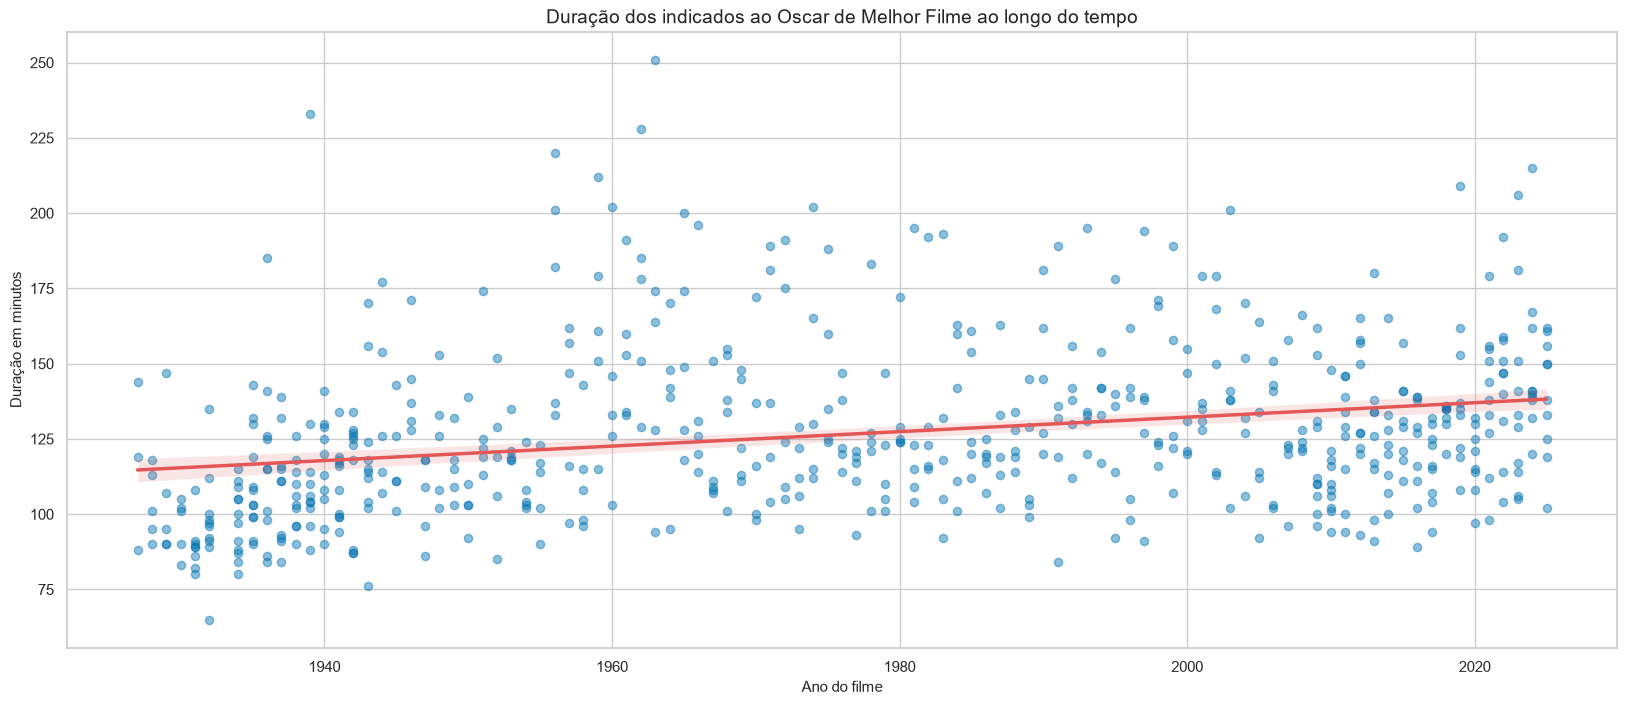

In [6]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.regplot(
    data=model_data,
    x="year_film",
    y="runtime_minutes",
    scatter_kws={"alpha": 0.45, "s": 35},
    line_kws={"color": "#E45756", "linewidth": 2.5},
    ax=ax,
)
ax.set_title("Duração dos indicados ao Oscar de Melhor Filme ao longo do tempo")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Duração em minutos")
plt.show()

## 5. Ajuste do modelo OLS

O modelo principal usa `year_film` em sua escala original para que o coeficiente angular represente diretamente minutos por ano. Também ajustamos uma versão com ano centralizado apenas para obter um intercepto mais interpretável; o coeficiente angular e o p-valor permanecem equivalentes.

In [7]:
X = sm.add_constant(model_data["year_film"])
y = model_data["runtime_minutes"]
ols_model = sm.OLS(y, X).fit()

X_centered = sm.add_constant(model_data["year_centered"])
ols_centered = sm.OLS(y, X_centered).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        runtime_minutes   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     49.56
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           5.14e-12
Time:                        08:38:19   Log-Likelihood:                -2916.1
No. Observations:                 621   AIC:                             5836.
Df Residuals:                     619   BIC:                             5845.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -348.1225     67.472     -5.160      0.0

## 6. Resultado inferencial do coeficiente angular

A tabela abaixo resume os valores necessários para a decisão estatística: estimativa de $\beta_1$, p-valor, intervalo de confiança e efeito acumulado no período observado.

In [8]:
slope = ols_model.params["year_film"]
intercept = ols_model.params["const"]
p_value = ols_model.pvalues["year_film"]
conf_low, conf_high = ols_model.conf_int(alpha=ALPHA).loc["year_film"]
r_squared = ols_model.rsquared
period_years = model_data["year_film"].max() - model_data["year_film"].min()
estimated_period_change = slope * period_years

inference_summary = pd.DataFrame(
    {
        "métrica": [
            "beta_0 intercepto",
            "beta_1 minutos por ano",
            "p-valor beta_1",
            f"IC {int((1 - ALPHA) * 100)}% beta_1 inferior",
            f"IC {int((1 - ALPHA) * 100)}% beta_1 superior",
            "R²",
            "mudança estimada no período observado",
        ],
        "valor": [
            intercept,
            slope,
            p_value,
            conf_low,
            conf_high,
            r_squared,
            estimated_period_change,
        ],
    }
)
inference_summary

,métrica,valor
0,beta_0 intercepto,-348.1225
1,beta_1 minutos por ano,0.2402
2,p-valor beta_1,0.0000
3,IC 95% beta_1 inferior,0.1732
4,IC 95% beta_1 superior,0.3072
5,R²,0.0741
6,mudança estimada no período observado,23.5370


In [9]:
if p_value < ALPHA and slope > 0:
    decision = "Rejeitar H0 e interpretar como evidência de aumento."
elif p_value < ALPHA and slope < 0:
    decision = "Rejeitar H0, mas a evidência aponta redução, não aumento."
else:
    decision = "Não rejeitar H0; não há evidência estatística suficiente de variação linear."

conclusion = pd.DataFrame(
    {
        "item": [
            "nível de significância",
            "p-valor beta_1",
            "beta_1 estimado",
            "decisão estatística",
            "interpretação operacional",
        ],
        "valor": [
            ALPHA,
            p_value,
            slope,
            decision,
            (
                f"A cada ano, a duração média estimada muda {slope:.3f} minutos. "
                f"No intervalo {model_data['year_film'].min()}-{model_data['year_film'].max()}, "
                f"isso equivale a aproximadamente {estimated_period_change:.1f} minutos."
            ),
        ],
    }
)
conclusion

,item,valor
0,nível de significância,0.0500
1,p-valor beta_1,0.0000
2,beta_1 estimado,0.2402
3,decisão estatística,Rejeitar H0 e interpretar como evidência de au...
4,interpretação operacional,"A cada ano, a duração média estimada muda 0.24..."


## 7. Reta estimada com agregação anual

Esta visualização mostra os pontos individuais, a média anual e a reta estimada pelo modelo. A agregação anual é apenas visual; o modelo principal usa as observações por filme.

In [10]:
yearly = (
    model_data.groupby("year_film", as_index=False)
    .agg(runtime_mean=("runtime_minutes", "mean"), nominees=("film", "count"))
)

year_grid = pd.DataFrame(
    {"year_film": np.arange(model_data["year_film"].min(), model_data["year_film"].max() + 1)}
)
year_grid = sm.add_constant(year_grid, has_constant="add")
prediction = ols_model.get_prediction(year_grid).summary_frame(alpha=ALPHA)
prediction["year_film"] = year_grid["year_film"].to_numpy()

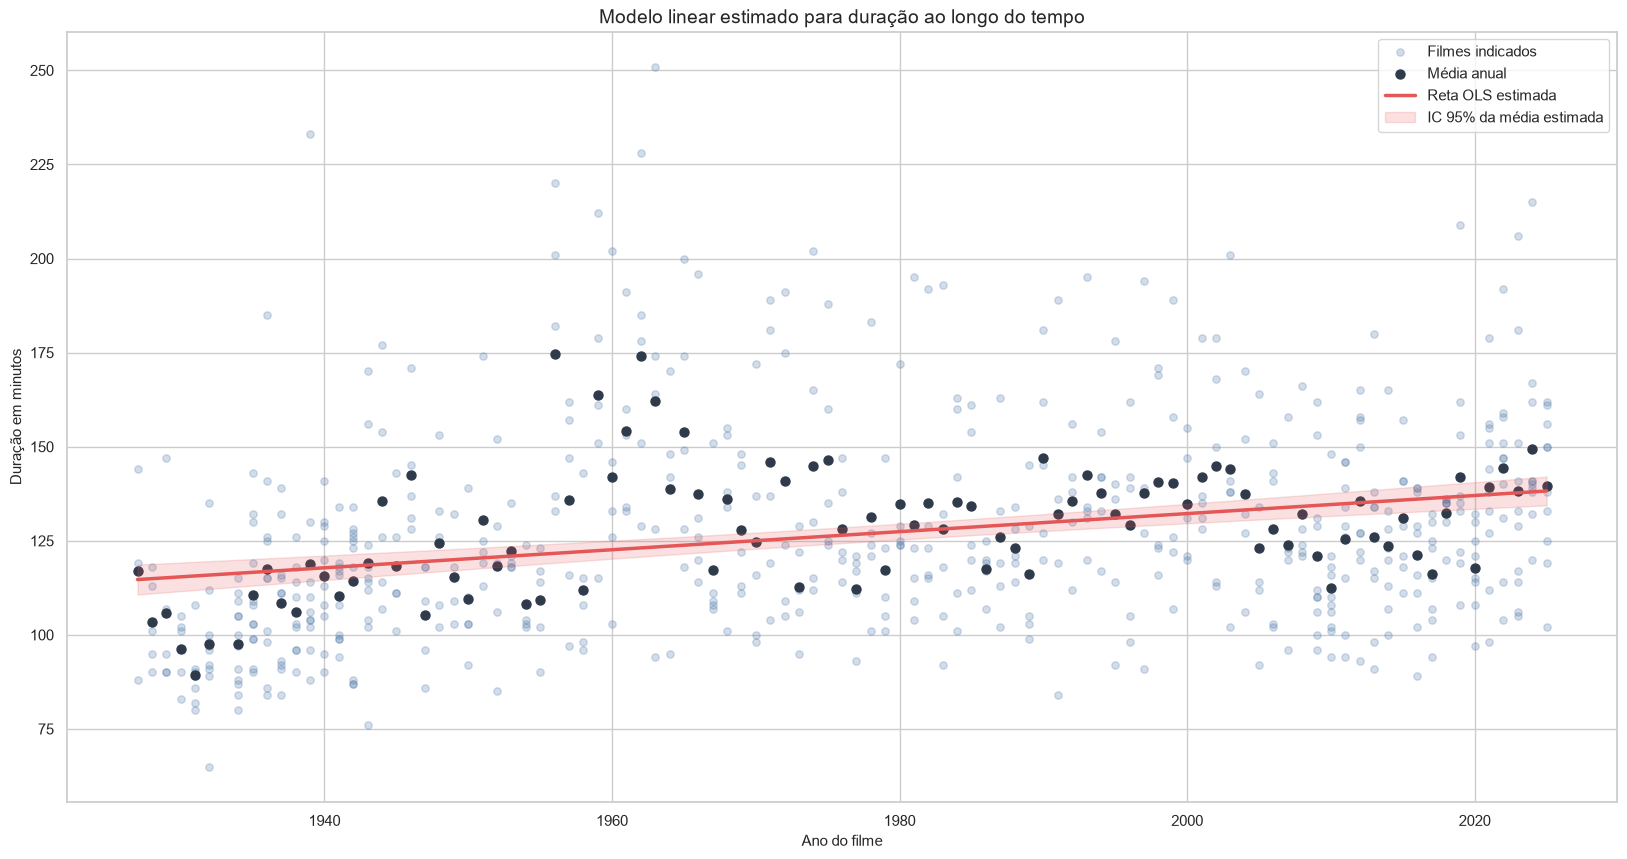

In [11]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.scatter(
    model_data["year_film"],
    model_data["runtime_minutes"],
    color="#4C78A8",
    alpha=0.25,
    s=28,
    label="Filmes indicados",
)
ax.scatter(
    yearly["year_film"],
    yearly["runtime_mean"],
    color="#2F3A4A",
    s=42,
    label="Média anual",
)
ax.plot(
    prediction["year_film"],
    prediction["mean"],
    color="#E45756",
    linewidth=2.5,
    label="Reta OLS estimada",
)
ax.fill_between(
    prediction["year_film"],
    prediction["mean_ci_lower"],
    prediction["mean_ci_upper"],
    color="#E45756",
    alpha=0.18,
    label=f"IC {int((1 - ALPHA) * 100)}% da média estimada",
)
ax.set_title("Modelo linear estimado para duração ao longo do tempo")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Duração em minutos")
ax.legend()
plt.show()

## 8. Diagnósticos de resíduos

A regressão linear simples pressupõe relação aproximadamente linear, resíduos sem padrão sistemático forte, variância aproximadamente constante e normalidade aproximada dos erros para inferência clássica em amostras pequenas. Com mais de 600 observações, a inferência tende a ser menos sensível a desvios moderados de normalidade, mas os diagnósticos continuam úteis.

In [12]:
diagnostics = model_data.copy()
diagnostics["fitted"] = ols_model.fittedvalues
diagnostics["residual"] = ols_model.resid
diagnostics["standardized_residual"] = ols_model.get_influence().resid_studentized_internal

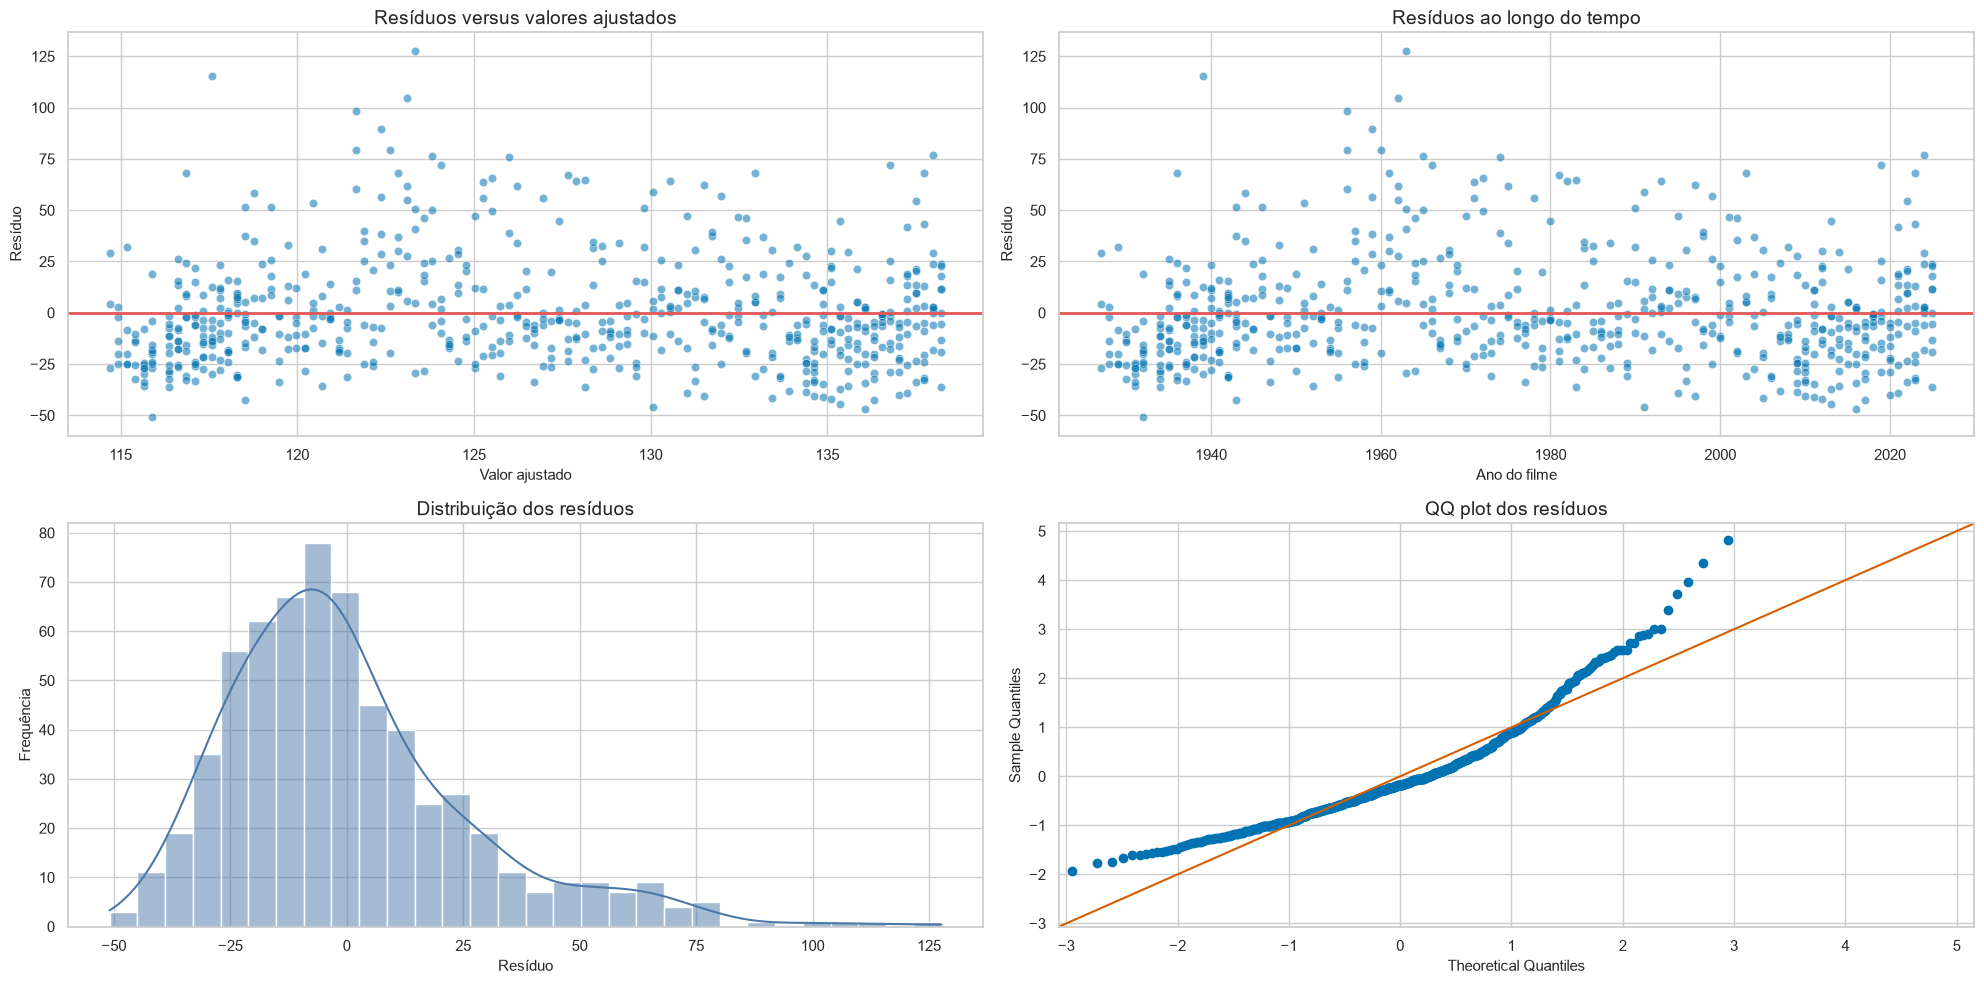

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.scatterplot(data=diagnostics, x="fitted", y="residual", alpha=0.55, ax=axes[0, 0])
axes[0, 0].axhline(0, color="#E45756", linewidth=2)
axes[0, 0].set_title("Resíduos versus valores ajustados")
axes[0, 0].set_xlabel("Valor ajustado")
axes[0, 0].set_ylabel("Resíduo")

sns.scatterplot(data=diagnostics, x="year_film", y="residual", alpha=0.55, ax=axes[0, 1])
axes[0, 1].axhline(0, color="#E45756", linewidth=2)
axes[0, 1].set_title("Resíduos ao longo do tempo")
axes[0, 1].set_xlabel("Ano do filme")
axes[0, 1].set_ylabel("Resíduo")

sns.histplot(diagnostics["residual"], bins=30, kde=True, color="#4C78A8", ax=axes[1, 0])
axes[1, 0].set_title("Distribuição dos resíduos")
axes[1, 0].set_xlabel("Resíduo")
axes[1, 0].set_ylabel("Frequência")

sm.qqplot(diagnostics["residual"], line="45", fit=True, ax=axes[1, 1])
axes[1, 1].set_title("QQ plot dos resíduos")

plt.tight_layout()
plt.show()

In [14]:
bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(
    ols_model.resid,
    ols_model.model.exog,
)
shapiro_stat, shapiro_pvalue = stats.shapiro(diagnostics["residual"])

robust_model = ols_model.get_robustcov_results(cov_type="HC3")
robust_params = pd.Series(robust_model.params, index=ols_model.params.index)
robust_pvalues = pd.Series(robust_model.pvalues, index=ols_model.params.index)
robust_conf_int = pd.DataFrame(
    robust_model.conf_int(alpha=ALPHA),
    index=ols_model.params.index,
    columns=["ci_low", "ci_high"],
)

diagnostic_tests = pd.DataFrame(
    {
        "teste": [
            "Breusch-Pagan heterocedasticidade",
            "Shapiro-Wilk normalidade dos resíduos",
            "p-valor beta_1 com erro padrão robusto HC3",
            "IC robusto HC3 beta_1 inferior",
            "IC robusto HC3 beta_1 superior",
        ],
        "valor": [
            bp_pvalue,
            shapiro_pvalue,
            robust_pvalues["year_film"],
            robust_conf_int.loc["year_film", "ci_low"],
            robust_conf_int.loc["year_film", "ci_high"],
        ],
    }
)
diagnostic_tests

,teste,valor
0,Breusch-Pagan heterocedasticidade,0.4535
1,Shapiro-Wilk normalidade dos resíduos,0.0000
2,p-valor beta_1 com erro padrão robusto HC3,0.0000
3,IC robusto HC3 beta_1 inferior,0.1791
4,IC robusto HC3 beta_1 superior,0.3012


## 9. Interpretação final

A decisão formal é baseada no p-valor do coeficiente angular da regressão linear simples. A leitura substantiva considera também o sinal de $\beta_1$.

In [15]:
print("Conclusão estatística")
print("-" * 24)
print(f"Modelo: runtime_minutes = beta_0 + beta_1 * year_film + epsilon")
print(f"alpha: {ALPHA:.2f}")
print(f"beta_1 estimado: {slope:.4f} minutos por ano")
print(f"p-valor de beta_1: {p_value:.6g}")
print(f"IC {(1 - ALPHA) * 100:.0f}% de beta_1: [{conf_low:.4f}, {conf_high:.4f}]")
print(f"R²: {r_squared:.4f}")
print(f"Decisão: {decision}")
print()
print(
    "Interpretação: dentro da proxy de indicados ao Oscar de Melhor Filme, "
    f"o modelo estima uma variação média de {slope:.3f} minutos por ano. "
    "Essa conclusão não implica causalidade e não deve ser generalizada automaticamente "
    "para todos os filmes lançados no mundo."
)

Conclusão estatística
------------------------
Modelo: runtime_minutes = beta_0 + beta_1 * year_film + epsilon
alpha: 0.05
beta_1 estimado: 0.2402 minutos por ano
p-valor de beta_1: 5.13879e-12
IC 95% de beta_1: [0.1732, 0.3072]
R²: 0.0741
Decisão: Rejeitar H0 e interpretar como evidência de aumento.

Interpretação: dentro da proxy de indicados ao Oscar de Melhor Filme, o modelo estima uma variação média de 0.240 minutos por ano. Essa conclusão não implica causalidade e não deve ser generalizada automaticamente para todos os filmes lançados no mundo.


## 10. Limitações

- A amostra é uma proxy composta por indicados ao Oscar de Melhor Filme, não pelo universo de filmes.
- A regressão linear simples estima uma tendência média linear; ela não captura quebras estruturais, efeitos não lineares ou mudanças nas regras da categoria.
- O p-valor indica evidência contra $H_0$ sob as premissas do modelo, mas não mede tamanho prático do efeito nem causalidade.
- Filmes indicados no mesmo ano podem compartilhar contexto histórico e industrial, então análises futuras podem considerar modelos por década, splines, regressão robusta ou agregação anual.